# Spatial maps of parameterized (GM) overturning

Local (non-zonally-summed) Gent-McWilliams overturning streamfunction, sliced
at a fixed depth (~1 km, near the GM overturning maximum), so the exact same
`z_l` level is shown on every panel.

The local streamfunction is the bottom-up cumulative sum of the GM bolus
transport `vhGM(z, y, x)` (converted to Sv), read directly from the archived
`*.mom6.h.z.*` history (years 10-20). No `Experiment` objects are needed.

**Experiments compared:** `CTRL` (deterministic GM) and `coupled_bANN_1.0`
(bANN backscatter). This isolates the grid-scale noise signature of the bANN
parameterization against the smooth deterministic GM baseline.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from mom6_tools.m6toolbox import genBasinMasks

plt.rcParams.update({'font.size': 14})

GM_YEARS = range(10, 21)   # years 10-20 inclusive
TARGET_DEPTH = 1000.0      # [m] fixed depth for the spatial slice (same on all panels)

# label -> (history dir, file prefix).  CTRL lives under a different archive.
GM_SPATIAL_CASES = {
    'GM (CTRL)': ('/glade/derecho/scratch/jiarongw/archive/CTRL/ocn/hist', 'CTRL'),
    'bANN':      ('/glade/derecho/scratch/pavelp/archive/coupled_bANN_1.0/ocn/hist', 'coupled_bANN_1.0'),
}

# Shared MOM6 grid -> read 2D v-point coords and basin codes once
_geom = xr.open_dataset('/glade/derecho/scratch/pavelp/archive/'
                        'coupled_bANN_1.0/ocn/hist/'
                        'coupled_bANN_1.0.mom6.h.ocean_geometry.nc')
GEOLON_V = _geom['geolonv'].values   # (yq, xh)
GEOLAT_V = _geom['geolatv'].values   # (yq, xh)

_depth = _geom['D'].values.copy()
_depth[np.isnan(_depth)] = 0.0
_bc = genBasinMasks(_geom['geolon'].values, _geom['geolat'].values, _depth,
                    verbose=False)


def _vmask2d(codes):
    """Tracer -> v-point mask (NaN outside), for the given basin codes."""
    m = np.isin(_bc, codes).astype(float)
    vm = m * np.roll(m, -1, axis=-2)
    return np.where(vm > 0, 1.0, np.nan)


_atl2d     = _vmask2d([2, 4, 6, 7, 8])              # Atlantic + Arctic + Med + Baltic + Hudson
_indopac2d = _vmask2d([3, 5])                       # Pacific + Indian
_glob2d    = _vmask2d(np.unique(_bc[_bc > 0]))      # all ocean cells
_lon_full  = (GEOLON_V.min(), GEOLON_V.max())

_psi1km_cache = {}   # prefix -> (unmasked map [Sv], depth used [m], n months)


def gm_psi_at_depth(hist, prefix, target_depth=TARGET_DEPTH):
    """Unmasked local GM overturning [Sv] at a fixed depth, dims (yq, xh); cached."""
    if prefix in _psi1km_cache:
        return _psi1km_cache[prefix]
    files = sorted(f for y in GM_YEARS
                   for f in glob.glob(f'{hist}/{prefix}.mom6.h.z.{y:04d}-*.nc'))
    ds = xr.open_mfdataset(files, combine='nested', concat_dim='time',
                           data_vars='minimal', coords='minimal',
                           compat='override', parallel=False,
                           preprocess=lambda d: d[['vhGM']])
    vhGM = ds['vhGM'].mean('time').compute().values      # (z_l, yq, xh)
    zl = ds['z_l'].values
    vh = np.ma.masked_invalid(vhGM).filled(0.) * 1.e-9   # -> Sv
    nz = vh.shape[0]
    psi = np.zeros((nz + 1,) + vh.shape[1:])
    for k in range(nz, 0, -1):                            # bottom-up cumulative
        psi[k - 1] = psi[k] - vh[k - 1]
    psi = 0.5 * (psi[:-1] + psi[1:])                     # to layer centres
    kz = int(np.argmin(np.abs(zl - target_depth)))       # fixed level
    _psi1km_cache[prefix] = (psi[kz], float(zl[kz]), len(files))
    return _psi1km_cache[prefix]


def plot_basin_spatial(mask2d, xlim, ylim, basin_name, vmax=0.3):
    """Side-by-side maps of the 1 km local GM overturning for a basin (masked)."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150,
                             sharex=True, sharey=True)
    z_used = None
    for ax, (label, (hist, prefix)) in zip(axes.flat, GM_SPATIAL_CASES.items()):
        smap, z_used, nfiles = gm_psi_at_depth(hist, prefix)
        smap = smap * mask2d
        pc = ax.pcolormesh(GEOLON_V, GEOLAT_V, smap, cmap='RdBu_r',
                           vmin=-vmax, vmax=vmax, shading='auto')
        ax.set_facecolor('lightgray')
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(f'{label}\n(|psi|max = {np.nanmax(np.abs(smap)):.2f} Sv, '
                     f'{nfiles} mo)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    fig.colorbar(pc, ax=axes, label=f'local GM overturning at {z_used:.0f} m [Sv]',
                 extend='both', shrink=0.8, pad=0.02)
    fig.suptitle(f'{basin_name} parameterized (GM) overturning at '
                 f'{z_used:.0f} m, years 10-20 [Sv]', fontsize=18, y=1.0)
    plt.show()

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


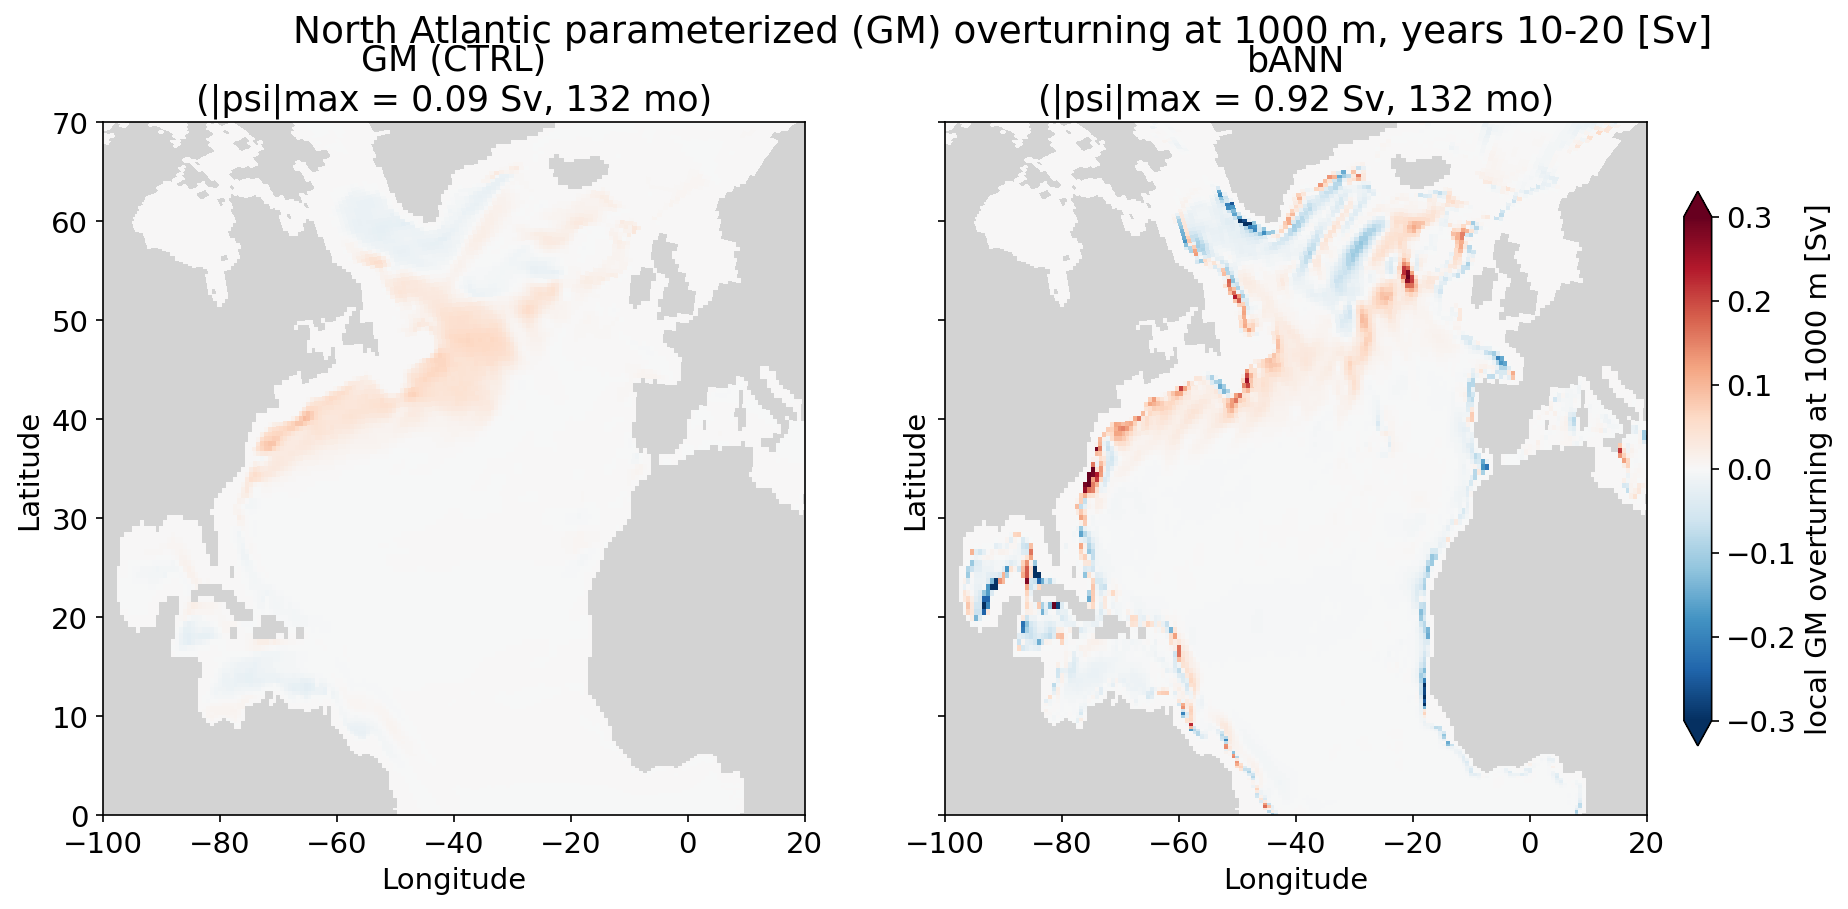

In [2]:
# North Atlantic
plot_basin_spatial(_atl2d, (-100, 20), (0, 70), 'North Atlantic')

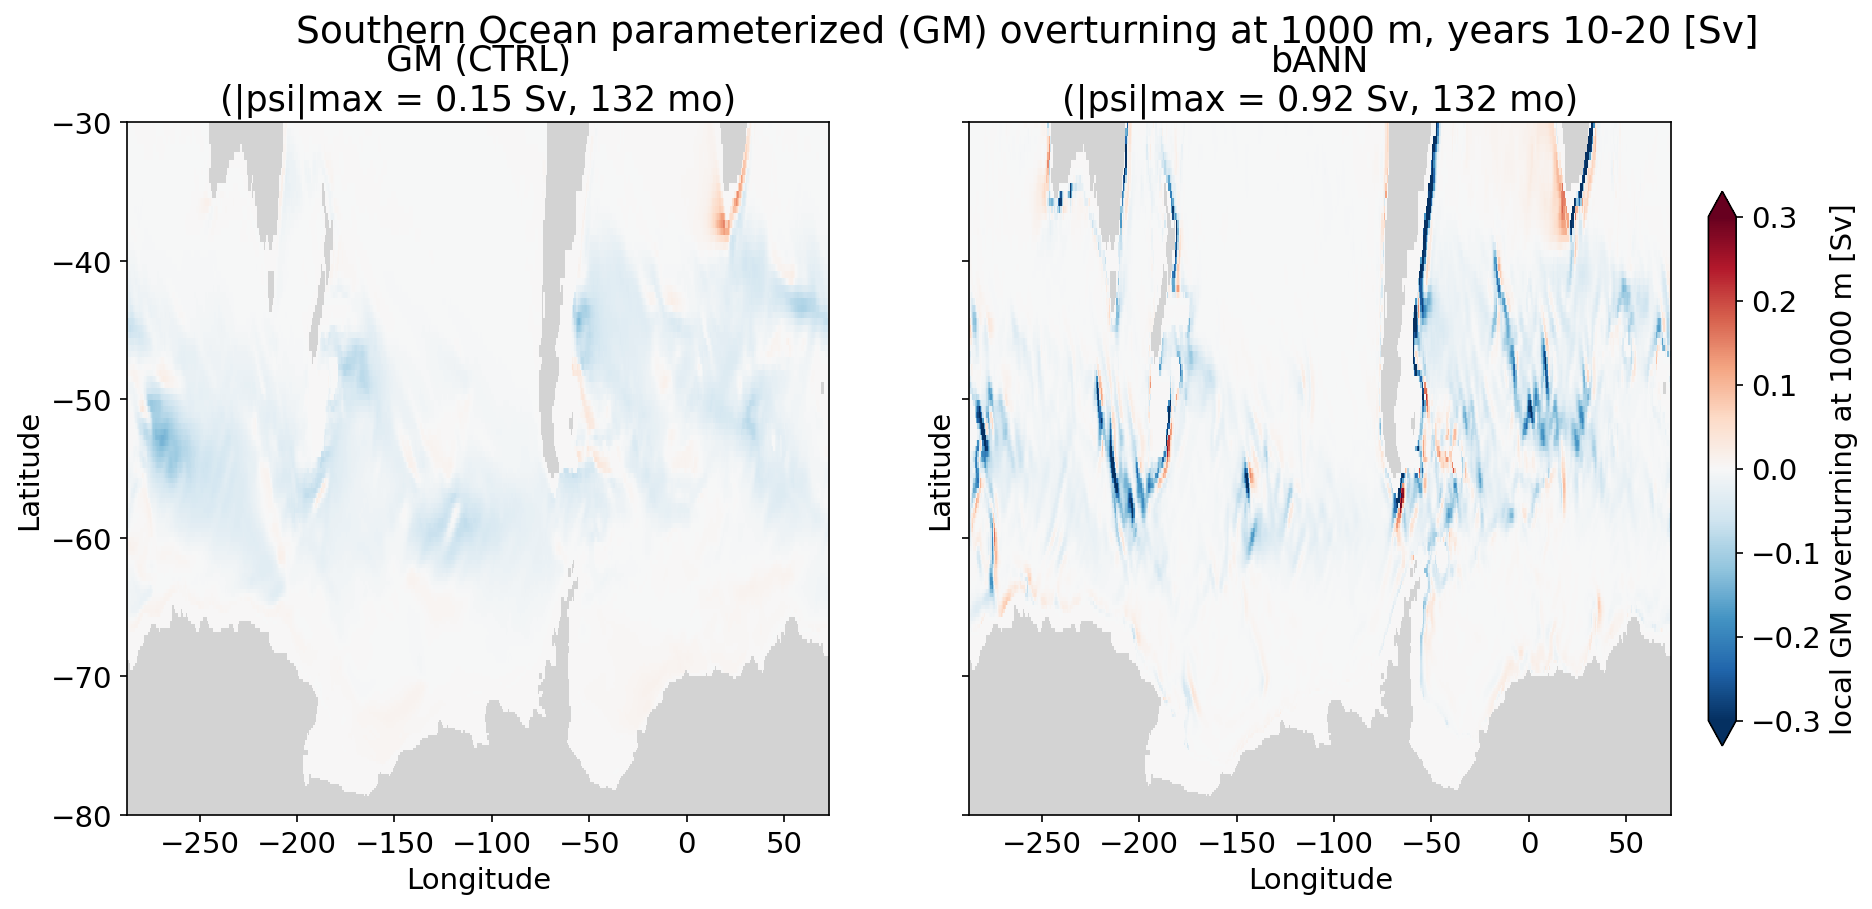

In [3]:
# Southern Ocean (circumpolar)
plot_basin_spatial(_glob2d, _lon_full, (-80, -30), 'Southern Ocean')

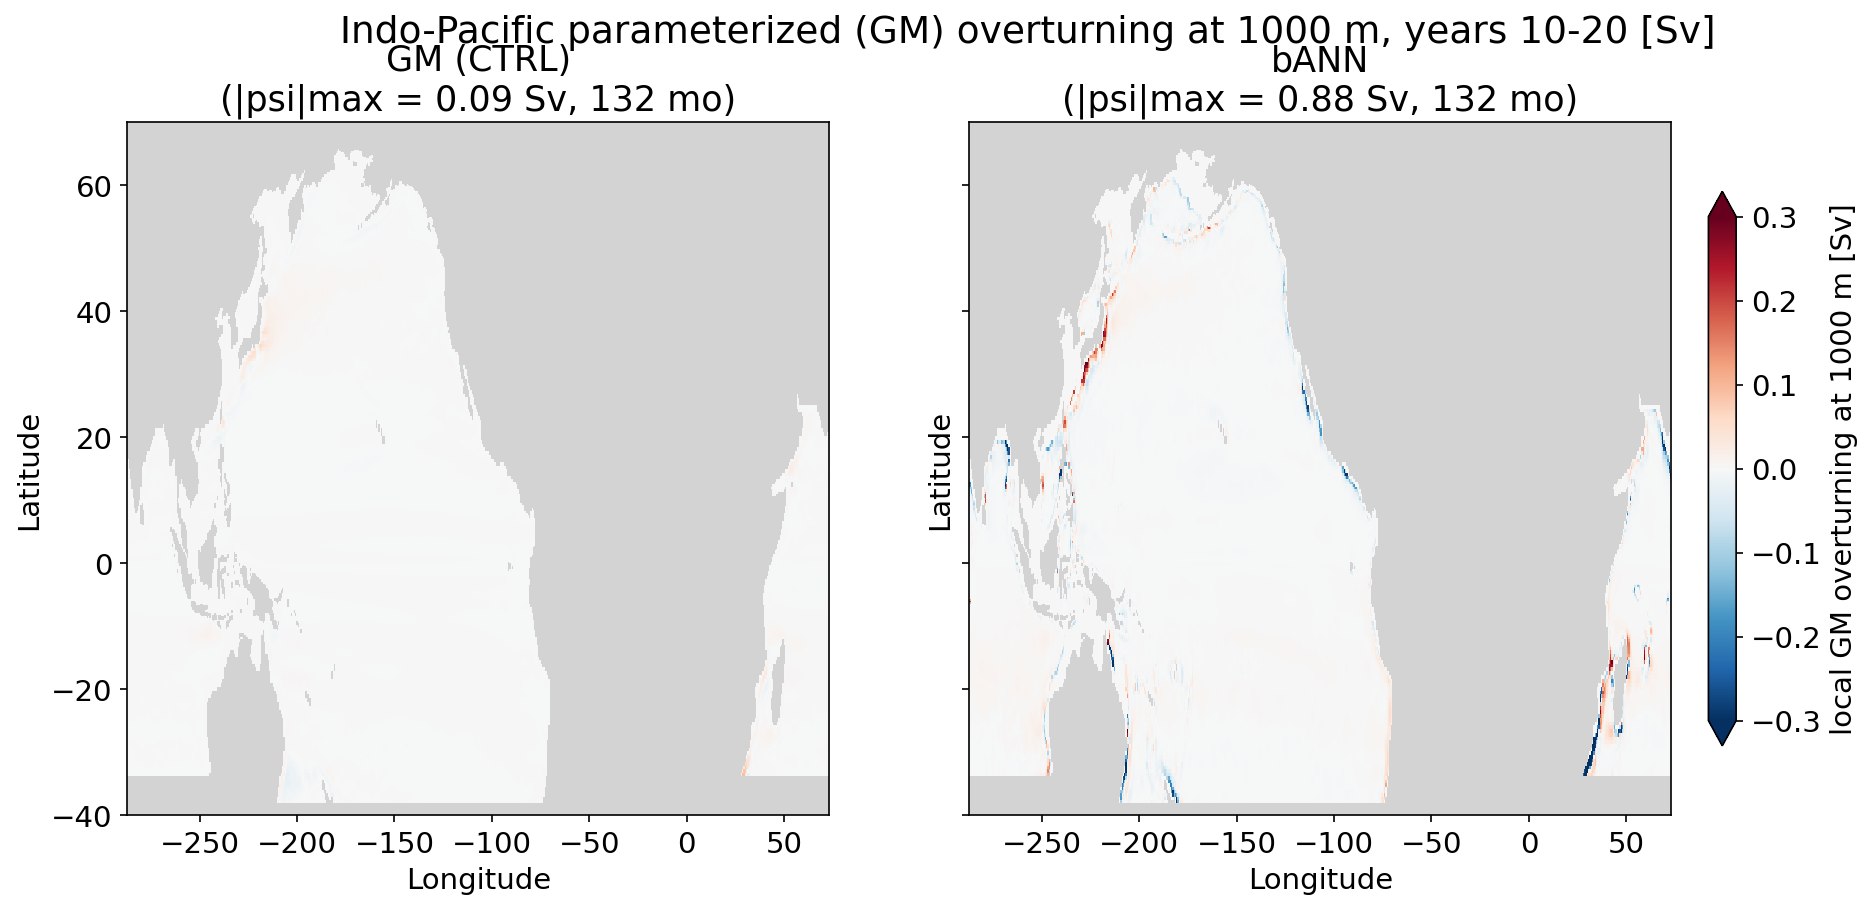

In [4]:
# Indo-Pacific
plot_basin_spatial(_indopac2d, _lon_full, (-40, 70), 'Indo-Pacific')